# <span style="color:green"> Lecture 09 notebook </span>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rc('font', size=14)

## <span style="color:blue">  Exercise 09.1 </span>

## <span style="color:black">  Struttura dell'algoritmo </span>

Il mio algoritmo genetico è stato strutturato nel seguente modo:
- Struct **city**: accetta due variabili di tipo _double_ per le coordinate spaziali _x_ e _y_;
- Struct **path**: è dotata di un vettore di interi, __sequence_, che rappresenta la codifica per il percorso, e di una variabile __length_, che rappresenta la lunghezza $L_1$ del percorso.
- Classe **population**: dotata di un vettore di **path**, (con poca fantasia) chiamato __paths_, di una matrice per le distanze tra le città precalcolata, in modo da non dover calcolare ogni volta tutte le distanze per tutti i percorsi, e del generatore di numeri casuali __rnd_.


## <span style="color:black">  Metodi principali </span>

- void **initialize**: alloca la matrice della distanze tra le città e genera i percorsi iniziale randomicamente. Per fare ciò, si inizializza un percorso ordinato: **_path$[i]$** = i, e lo si disordina. inizialmente avevo utilizzato $100$ swap casuali per questa fase, ma documentandomi alla ricerca di una maggior efficienza ho scopeerto lo shuffle di Fisher-Yates, che garantisce una permutazione senza alcun bias in $N$ passi. Questo algoritmo parte dal fondo del **_path**, e scambia l'ultima città, j-esima, con una estratta casualmente tra quella che la precedono. A questo punto j diminuisce di 1, fino ad arrivare alla città in posizione 2;

- bool **check**: funzione di controllo che non ci siano stati errori nel corso dell'evoluzione. Quando chiamata, controlla che la **_sequence** corrispondente al **_path** passato come argomento sia della lunghezza giusta, inizi con la città selezionata come inizio del viaggio, e che ciascuna città compaia una sola volta;

  
- int **select_parent**: seleziona un genitore per la generazione successiva. Restituisce un intero scelto come $j =$**\_npaths** $\cdot r^p$, con $r \in [0, 1)$ estratto casualmente dal generatore di numeri casuali, e $p=3$. Prima di chiamare questo metodo è necessario aver ordinato il vettore percorsi in funzione della loro lunghezza;

  
- void **mutation_swap**: scambia due città del percorso passato come argomento, estratte casualmente. Per esempio,, per uno scambio di terza e quarta città: $$\left[ 1, 2, 3, 4, 5 \right] \to \left[ 1, 2, 4, 3, 5 \right];$$

  
- void **mutation_global_shift**: estrae casualmente il numero di posizioni di cui shiftare l'intera sequenza. Assegna i nuovi indici sommando all'indice attuale l'intero di cui si desidera shiftare. Sono applicate PBC per ricondurre indici $>=$**_ncities** all'interno della sequenza, secondo la formula **index** $= 1 + ($**newindex**$ - 1)\% ($**_ncities** $ -1)$. Per esempio, per uno shift di $2$ posizioni: $$\left[ 1, 2, 3, 4, 5 \right] \to \left[ 1, 4, 5, 2, 3 \right] ;$$

  
- void **mutation_swap_block**: scambia due sequenze di città adiacenti. Estrae un intero **m** $\in [1,$ **int**$(($**_ncities**$ -1)/2))$, e un altro intero **start**$ \in [1, ($**_ncities**$ -2m +1))$. Scambia le **m** città comprese tra **start** e **start2** $=$ **start + m** con le **m** città successive. Per esempio, per scambio di seconda e terza città con le $2$ città successive: $$\left[ 1, 2, 3, 4, 5 \right] \to \left[ 1, 4, 5, 2, 3 \right]; $$

  
- void **mutation_reverse**: inverte le città comprese tra due interi casuali **start** e **end**, estratti casualmente tra $[1, $**_ncities**$)$ e col vincolo **end** $>$ **start**. Per esempio, per inversione di seconda e terza città: $$\left[ 1, 2, 3, 4, 5 \right] \to \left[ 1, 4, 3, 2, 5 \right];$$

- void **crossover**: riceve come argomento i due percorsi selezionati da una chiamata di **select_parent**. Copia i due percorsi **mom** e **dad** in due percorsi **son1 = dad** e **son2 = mom**. Estrae un intero casuale che funge come indice di taglio **cut**. Esegue un doppio ciclo su tutte le città di **dad** e su quelle dim**son2** posizionate prima dell'indice di taglio. Se non ci sono corrispondenze, la città del padre viene sostituita alla città all'indice **fill_index = cut** del figlio, che viene aggiornato come **fill_index++**. Ripete l'operaione per **mom** e **son1**. Per esempio, avendo seelzionato un padre e una madre: $$
\left[ 1, 2, 3, 4, 5 \right]\\
\left[ 1, 5, 4, 3, 2 \right] 
$$
1. Si tagliano i percorsi allo stesso indice **cut**:
$$
\left[ 1, 2, 3 | 4, 5 \right]\\
\left[ 1, 5, 4 | 3, 2 \right] 
$$
2. Si conserva la prima parte del percorso:
$$
\left[ 1, 2, 3 | X, Y \right]\\
\left[ 1, 5, 4 | X, Y \right] 
$$
3. Si completano i percorsi con le città mancanti, controllando che non siano già presenti nella prima parte, nell'ordine in cui appaiono nel partner:
$$
\left[ 1, 2, 3 | 5, 4 \right]\\
\left[ 1, 5, 4 | 2, 3 \right] 
$$

- void **evolve**: chiama due volte **select_parent**. Con probabilità del $70\%$, applica **crossover** ai due figli. Con probabilità dell'$8\%$ ciascuna applica le mutazioni ai figli. Controlla che non ci siano stati errori nelle fasi di **crossover** e mutazione, e inserisce i figli nel vector<path> **next_generation**, allocato in precedenza. Ripete fin tanto che la generazioni successiva non ha raggiunto le dimensioni della generazione precedente.

## <span style="color:black">  Considerazioni e parametri dell'esercizio </span>

Il valore di $p$ nell'algoritmo **select_parent** è stato variato più volte, e alla fine $3$ mi è sembrato un valore ragionevole. Ho osservato come aumentare questo numero portasse l'algoritmo a incagliarsi in minimi locali, mentre ridurlo troppo, rallentase di molto la convergenza.

Le probabilità di mutazione **crossover** sono state variate entro i limiti prescritti, e alla fine ho optato per questi valori.

Ho assegnato alla popolazione una dimensione di $100$ elementi. Provando a variare questo numero, può forse essere anche ridotto, ma così l'algoritmo sembra funzionare e sembra farlo in tempi ragionevoli in termini di generazioni.

Sono state compiute $50000$ generazioni di evoluzione.

## <span style="color:black">  Mappa circolare </span>

lunghezza del miglior percorso 6.26143


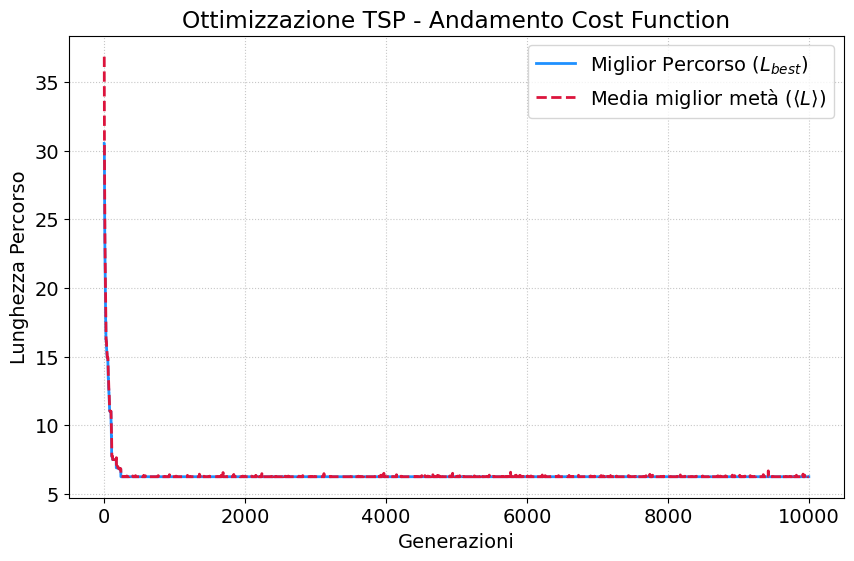

In [17]:

generations, best_length, mean_length = np.loadtxt('metrics.dat', unpack=True)
print(f"lunghezza del miglior percorso", best_length[-1])
plt.figure(figsize=(10, 6))

plt.plot(generations, best_length, label=r'Miglior Percorso ($L_{best}$)', color='dodgerblue', linewidth=2)

plt.plot(generations, mean_length, label=r'Media miglior metà ($\langle L \rangle$)', color='crimson', linestyle='--', linewidth=2)

plt.title(r"Ottimizzazione TSP - Andamento Cost Function")
plt.xlabel("Generazioni")
plt.ylabel("Lunghezza Percorso")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

plt.show()

Come possiamo vedere nei dettagli, l'algoritmo è molto veloce a decrescere nelle prime fasi della sua evoluzione. Già dopo $250$ generazioni l'algoritmo aveva trovato l'ottimo. In particolare, la media della miglior metà collassa molto più velocemente di quanto mi sarei aspettato sulla lunghezza del percorso migliore. Questo potrebbe essere effetto della semplicità del percorso da trovare, o sintomo di una scarsa diversificazione nell'algoritmo e quindi causa di problemi in caso di percorsi più difficili.

Per quanto riguarda i distaccamenti della media della miglior metà dei percorsi dall'ottimo nella fase finale di evoluzione dell'algoritmo, tendo ad apprezzare questo comportamento: in una popolazione con pochissima diversità, esistono comunque le occasioni per uscire da eventuali minimi locali. Anzi, queste potrebbero forse essere aumentate per aiutare l'algoritmo in caso di ottimi più difficili da trovare

lunghezza del miglior percorso dopo 200 generazioni 6.90452
lunghezza del miglior percorso dopo 250 generazioni 6.26143
lunghezza del miglior percorso 6.26143


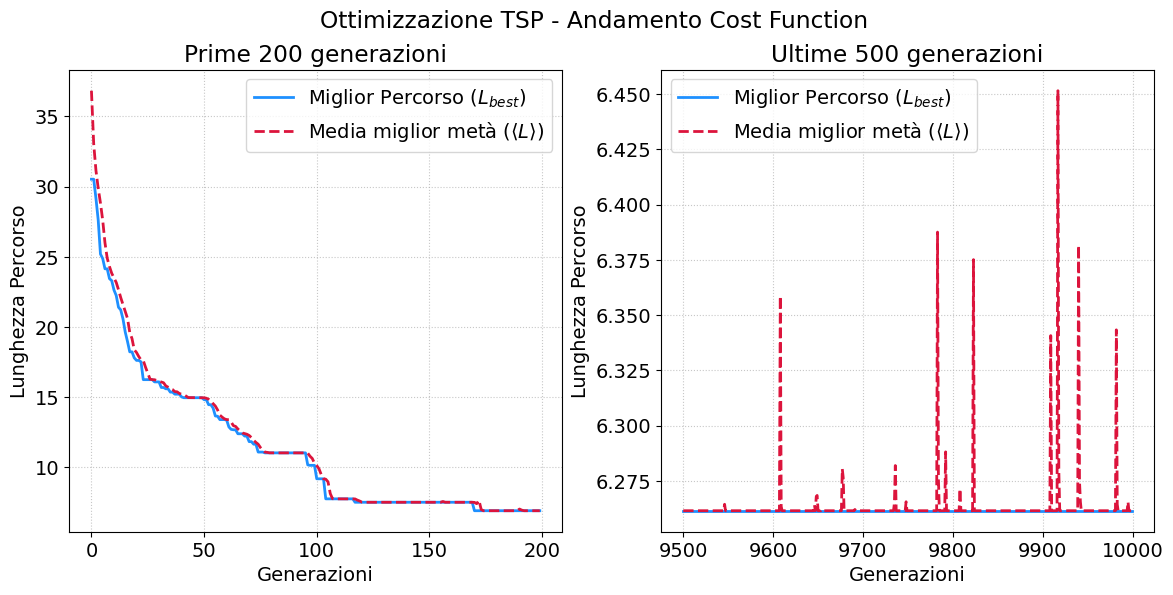

In [27]:
fig, axes = plt.subplots(1, 2, figsize = (14, 6))

print(f"lunghezza del miglior percorso dopo 200 generazioni", best_length[200])
print(f"lunghezza del miglior percorso dopo 250 generazioni", best_length[250])
print(f"lunghezza del miglior percorso", best_length[-1])
axes[0].plot(generations[0:200], best_length[0:200], label=r'Miglior Percorso ($L_{best}$)', color='dodgerblue', linewidth=2)

axes[0].plot(generations[0:200], mean_length[0:200], label=r'Media miglior metà ($\langle L \rangle$)', color='crimson', linestyle='--', linewidth=2)

axes[0].set_title(r"Prime 200 generazioni")
axes[0].set_xlabel("Generazioni")
axes[0].set_ylabel("Lunghezza Percorso")
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.7)

axes[1].plot(generations[9500:10000], best_length[9500:10000], label=r'Miglior Percorso ($L_{best}$)', color='dodgerblue', linewidth=2)

axes[1].plot(generations[9500:10000], mean_length[9500:10000], label=r'Media miglior metà ($\langle L \rangle$)', color='crimson', linestyle='--', linewidth=2)

axes[1].set_title(r"Ultime 500 generazioni")
axes[1].set_xlabel("Generazioni")
axes[1].set_ylabel("Lunghezza Percorso")
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.7)

plt.suptitle(r"Ottimizzazione TSP - Andamento Cost Function")

plt.show()

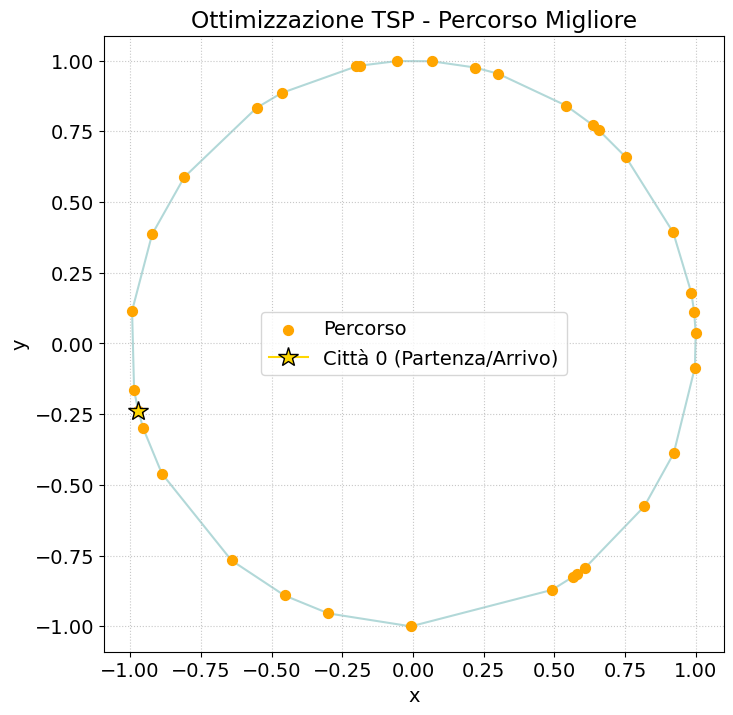

In [9]:
x, y = np.loadtxt('best_path.dat', unpack=True)


plt.figure(figsize=(8, 8))

plt.plot(x, y, marker='o', markersize=6, linestyle='-', alpha = 0.3, zorder = 1, color='teal')
plt.scatter(x, y, color='orange', s=50, zorder = 3, label='Percorso')

plt.plot(x[0], y[0], marker='*', markersize=15, color='gold', markeredgecolor='black', zorder = 10, label='Città 0 (Partenza/Arrivo)')

# Aggiunge i numeri delle città vicino ai punti
#for i in range(len(x)-1):
#    plt.text(x[i], y[i], f" {i}", fontsize=15, color='darkred')

plt.title("Ottimizzazione TSP - Percorso Migliore")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

plt.axis('equal') 

plt.show()

## <span style="color:black">  Mappa quadrata </span>

lunghezza del miglior percorso 4.98426
4.98426


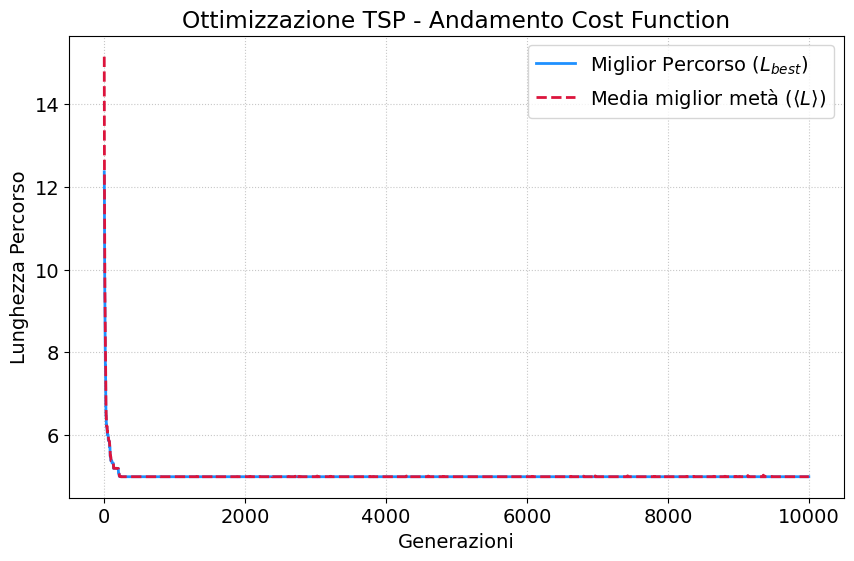

In [28]:
generations, best_length, mean_length = np.loadtxt('square_metrics.dat', unpack=True)
print(f"lunghezza del miglior percorso", best_length[-1])

plt.figure(figsize=(10, 6))

plt.plot(generations, best_length, label=r'Miglior Percorso ($L_{best}$)', color='dodgerblue', linewidth=2)

plt.plot(generations, mean_length, label=r'Media miglior metà ($\langle L \rangle$)', color='crimson', linestyle='--', linewidth=2)

plt.title(r"Ottimizzazione TSP - Andamento Cost Function")
plt.xlabel("Generazioni")
plt.ylabel("Lunghezza Percorso")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

plt.show()

lunghezza del miglior percorso dopo 200 generazioni 5.13203
lunghezza del miglior percorso dopo 250 generazioni 4.98426
lunghezza del miglior percorso 4.98426


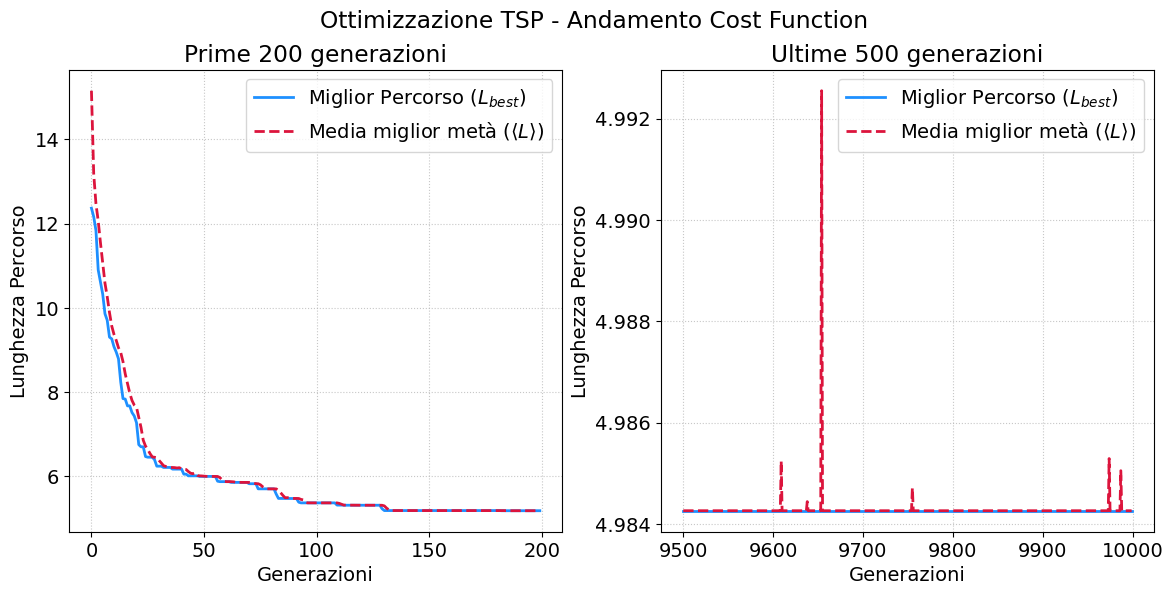

In [29]:
fig, axes = plt.subplots(1, 2, figsize = (14, 6))
print(f"lunghezza del miglior percorso dopo 200 generazioni", best_length[200])
print(f"lunghezza del miglior percorso dopo 250 generazioni", best_length[250])
print(f"lunghezza del miglior percorso", best_length[-1])

axes[0].plot(generations[0:200], best_length[0:200], label=r'Miglior Percorso ($L_{best}$)', color='dodgerblue', linewidth=2)

axes[0].plot(generations[0:200], mean_length[0:200], label=r'Media miglior metà ($\langle L \rangle$)', color='crimson', linestyle='--', linewidth=2)

axes[0].set_title(r"Prime 200 generazioni")
axes[0].set_xlabel("Generazioni")
axes[0].set_ylabel("Lunghezza Percorso")
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.7)

axes[1].plot(generations[9500:10000], best_length[9500:10000], label=r'Miglior Percorso ($L_{best}$)', color='dodgerblue', linewidth=2)

axes[1].plot(generations[9500:10000], mean_length[9500:10000], label=r'Media miglior metà ($\langle L \rangle$)', color='crimson', linestyle='--', linewidth=2)

axes[1].set_title(r"Ultime 500 generazioni")
axes[1].set_xlabel("Generazioni")
axes[1].set_ylabel("Lunghezza Percorso")
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.7)

plt.suptitle(r"Ottimizzazione TSP - Andamento Cost Function")

plt.show()

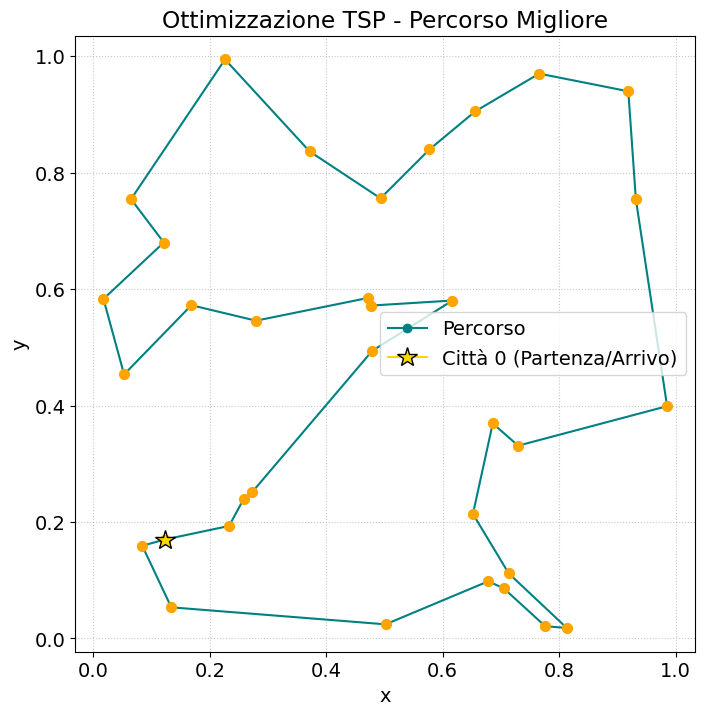

In [9]:
x, y = np.loadtxt('square_best_path.dat', unpack=True)

plt.figure(figsize=(8, 8))

plt.plot(x, y, marker='o', markersize=6, linestyle='-', color='teal', label='Percorso')
plt.scatter(x, y, color='orange', s=50, zorder = 3)

plt.plot(x[0], y[0], marker='*', markersize=15, color='gold', markeredgecolor='black', zorder = 10, label='Città 0 (Partenza/Arrivo)')

# Aggiunge i numeri delle città vicino ai punti
#for i in range(len(x)-1):
#   plt.text(x[i], y[i], f" {i}", fontsize=9, color='darkred')

plt.title("Ottimizzazione TSP - Percorso Migliore")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

plt.axis('equal') 

plt.show()

Anche in questo caso, dove il minimo potrebbe sembrare più difficile da raggiungere rispetto alla mappa precdente, sembra che l'algoritmo riesca a raggiungerlo e riesca a farlo piuttosto in fretta.

Ancora una volta, infatti, dopo $250$ generazioni l'algoritmo aveva trovato il minimo.

Per quanto riguarda la convergenza della media della migliore metà al momentaneo **best_path**, questa si verifica in modo qualitativamente simile all'esercizio precdente per questa mappa (convergenza già entro le prime $200$ generazioni), ma non sembra essere un problema troppo grave.